<a href="https://colab.research.google.com/github/T-Svitlichna/DTA_Python/blob/main/ML/LinearRegression_DTA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
model = LinearRegression()

# Щоб результати були однаковими щоразу (відтворюваність)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Бібліотеки готові ✅")

Бібліотеки готові ✅


У реальній роботі завантажте CSV через `pd.read_csv("file.csv")`.

**Генеруємо дані**  
Створюємо таблицю з ознаками й «справжньою» ціною (з невеликим випадковим шумом, як у житті).

In [22]:
n = 1000  # скільки квартир

area      = np.random.normal(60, 20, n).clip(20, 140)        # площа, м²
rooms     = np.clip(np.round(area / 25 + np.random.normal(0, 0.6, n)), 1, 5)  # кімнати
floor     = np.random.randint(1, 25, n)                      # поверх
dist_km   = np.random.exponential(5, n).clip(0.3, 25)        # відстань до центру, км
age_years = np.random.randint(0, 60, n)                      # вік будинку, років

# "Справжня" логіка ціни (у тис. $) — у житті її НЕ знаємо, модель має її відкрити:
price = (
    40                       # базова
    + area * 1.8             # кожен м² додає
    + rooms * 5              # кожна кімната
    + floor * 0.4            # трохи за поверх
    - dist_km * 3.0          # далі від центру — дешевше
    - age_years * 0.5        # старіший будинок — дешевше
    + np.random.normal(0, 12, n)   # шум: усе інше, що ми не врахували
).clip(20, None)

df = pd.DataFrame({
    "area": area.round(1),
    "rooms": rooms.astype(int),
    "floor": floor,
    "dist_km": dist_km.round(1),
    "age_years": age_years,
    "price": price.round(1),
})

df.head()


,area,rooms,floor,dist_km,age_years,price
0,69.9,4,6,2.6,14,172.1
1,57.2,3,11,6.4,30,122.8
2,73.0,3,3,2.4,54,146.3
3,90.5,3,8,3.4,13,217.6
4,55.3,3,3,2.8,10,165.2


In [23]:
len(df)
print(df.shape[0], df.shape[1])

1000 6


In [24]:
print("Пропуски - ", df.isna().sum().sum())
#

Пропуски -  0


In [25]:
df.describe()

,area,rooms,floor,dist_km,age_years,price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,60.492200,2.479000,12.686000,4.958100,30.391000,136.250900
std,19.328422,0.951033,7.004889,4.708852,17.232326,44.993968
min,20.000000,1.000000,1.000000,0.300000,0.000000,20.000000
25%,47.075000,2.000000,6.000000,1.500000,16.000000,104.150000
50%,60.500000,2.000000,13.000000,3.600000,30.000000,136.750000
75%,73.000000,3.000000,19.000000,7.000000,45.250000,165.450000
max,137.100000,5.000000,24.000000,25.000000,59.000000,282.400000


Text(0.5, 1.0, 'Залежність ціни від площі')

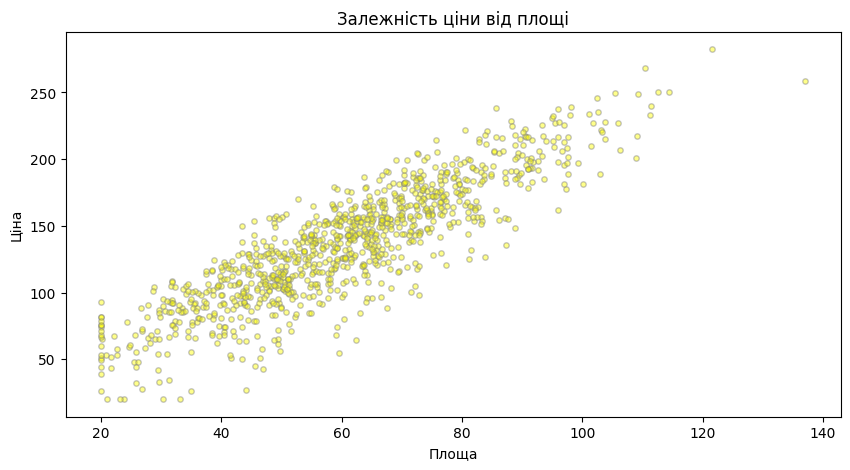

In [26]:

fig = plt.figure(figsize=(10, 5))
plt.scatter(df["area"], df["price"], edgecolors="grey", color="yellow", alpha=0.46, s=15)
plt.xlabel("Площа")
plt.ylabel("Ціна")
plt.title("Залежність ціни від площі")





In [27]:
df.columns

Index(['area', 'rooms', 'floor', 'dist_km', 'age_years', 'price'], dtype='object')

In [28]:
X = df[['area', 'rooms', 'floor', 'dist_km', 'age_years']] # features
y = df["price"] # target
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)
print("Навчальна вибірка", X_train.shape, "\n", "Тестова вибірка", X_test.shape)

Навчальна вибірка (800, 5) 
 Тестова вибірка (200, 5)


| X | y | **X_train** | X_test | **y_train** | y_test | y_pred |
| - | - | ------- | ------ | ------- | ------ | -- |
| 1 | 1 | 1 |  | 1 |  |  |
| 2 | 4 | 2 |  | 4 |  |  |
| 3 | 9 |  | 3 |  | 9 | 90 |
| 4 | 16 | 4 |  | 16 |  |  |
| 5 | 25 |  | 5 |  | 25 | 250 |
| 6 | 36 | 6 |  | 36 |  |  |
| 7 | 49 | 7 |  | 49 |  |  |
| 8 | 64 | 8 |  | 64 |  |  |
| 9 | 81 | 9 |  | 81 |  |  |
| 10 | 100 | 10 |  | 100 |  |  |
| 11 |  |  |  |  |  | 1210 |

In [29]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

compare = pd.DataFrame({
    "Actual": y_test[:5].round(),
    "Predicted": y_pred[:5].round()

})
compare["error"] = compare["Actual"] - compare["Predicted"]
compare

,Actual,Predicted,error
521,119.0,130.0,-11.0
737,173.0,178.0,-5.0
740,20.0,26.0,-6.0
660,94.0,111.0,-17.0
411,101.0,97.0,4.0


In [30]:
#MAE # mean absolut error на скільки наша модель помилилися в середньому


In [31]:
#MSE # mean scquare error

In [32]:
#RMSE # показує *(корінь квадратний з MSE) - чим меньше значення тим краще

In [33]:
#R² - яку частину розкиду модель може оцінити [0:1.0] 1ideal, - 0 вгадує середній показник

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.1f}K $ in mean error")
print(f"MSE: {mse:.1f}K $")
print(f"RMSE: {rmse:.2f}K $")
print(f"R²: {r2*100:.3f} model describe % from real price")

MAE: 8.7K $ in mean error
MSE: 117.3K $
RMSE: 10.83K $
R²: 94.699 model describe % from real price


In [35]:
coef = pd.DataFrame({
    "features" : X.columns,
    "coef" : model.coef_.round(2)
    }).sort_values(by="coef", ascending=False)
print("Basic Prica", model.intercept_.round(2), "K $")
print("Depends of price")

coef


Basic Prica 40.83 K $
Depends of price


,features,coef
1,rooms,5.22
0,area,1.78
2,floor,0.39
4,age_years,-0.49
3,dist_km,-3.07


In [46]:
new_flat = pd.DataFrame([{
    'area':68, 'rooms':2, 'floor':2, 'dist_km':15, 'age_years':10
}])
new_flat
print(f"+/-: {mae:.1f} тис дол.")
print("Ймовірна ціна:", f"{model.predict(new_flat)[0]:.2f}")
#print(f"Яке рішення прийме: {"Піде" if model.predict(new_client)[0] else "Залишиться"}" )
#

+/-: 8.7 тис дол.
Ймовірна ціна: 122.36
